# Лабораторна робота №4
## Розгортання моделі глибокого навчання як REST-API з використанням FastAPI, ONNX Runtime та Docker

**Мета:** Опанувати методи розгортання моделей глибокого навчання за допомогою FastAPI, ONNX Runtime (CPU / CUDA / TensorRT) та Docker.

## 1. Встановлення залежностей

In [ ]:
%pip install onnxruntime-gpu fastapi uvicorn[standard] python-multipart httpx Pillow numpy pydantic -q

## 2. Експорт моделі у формат ONNX

In [1]:
import os, sys
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

# Paths
LAB3_DIR  = os.path.abspath("../L3")
LAB4_DIR  = os.path.abspath(".")
CKPT_PATH = os.path.join(LAB3_DIR, "checkpoints", "resnet50_phase2.pt")
ONNX_PATH = os.path.join(LAB4_DIR, "model.onnx")
NUM_CLASSES = 196

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

def build_resnet50(num_classes: int) -> nn.Module:
    model = resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_features, num_classes))
    return model

model = build_resnet50(NUM_CLASSES)
state = torch.load(CKPT_PATH, map_location=device)
if isinstance(state, dict) and "model_state_dict" in state:
    state = state["model_state_dict"]
model.load_state_dict(state)
model.eval().to(device)
print("Checkpoint loaded.")

Device: cuda
Checkpoint loaded.


In [2]:
dummy = torch.randn(1, 3, 224, 224, device=device)

torch.onnx.export(
    model, dummy, ONNX_PATH,
    input_names=["image"],
    output_names=["logits"],
    dynamic_axes={"image": {0: "batch"}, "logits": {0: "batch"}},
    opset_version=17,
    do_constant_folding=True,
)
size_mb = os.path.getsize(ONNX_PATH) / 1e6
print(f"Exported → {ONNX_PATH}  ({size_mb:.1f} MB)")

/tmp/ipykernel_26575/3265026463.py:3: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0510 15:54:54.376000 26575 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0510 15:54:54.898000 26575 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int'

[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib64/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/plat-fedora/Projects/venvs/torch-3.12/lib64/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/plat-fedora/Projects/venvs/torch-3.12/lib64/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/home/plat-fedora/Project

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Exported → /home/plat-fedora/Projects/git-cloned/MTDL-NULP/L4/model.onnx  (0.2 MB)


## 3. Збереження назв класів Stanford Cars

In [3]:
import kagglehub
from torchvision.datasets import StanfordCars
import torchvision.transforms as T

_raw = kagglehub.dataset_download("eduardo4jesus/stanford-cars-dataset")
_ds  = StanfordCars(root=_raw, split="train",
                    transform=T.Compose([T.Resize((224,224)), T.ToTensor()]),
                    download=False)
CLASS_NAMES = _ds.classes
print(f"Classes: {len(CLASS_NAMES)} — e.g. {CLASS_NAMES[:3]}")

CLASS_NAMES_FILE = os.path.join(LAB4_DIR, "app", "class_names.txt")
with open(CLASS_NAMES_FILE, "w") as f:
    f.write("\n".join(CLASS_NAMES))
print(f"Saved → {CLASS_NAMES_FILE}")

Classes: 196 — e.g. ['AM General Hummer SUV 2000', 'Acura RL Sedan 2012', 'Acura TL Sedan 2012']
Saved → /home/plat-fedora/Projects/git-cloned/MTDL-NULP/L4/app/class_names.txt


## 4. Перевірка ONNX-моделі та інференс через ONNX Runtime

In [4]:
import onnx
import onnxruntime as ort
import numpy as np

# Validate graph
onnx_model = onnx.load(ONNX_PATH)
onnx.checker.check_model(onnx_model)
print("ONNX model graph check: OK")
print(f"ORT version: {ort.__version__}")
print(f"Available providers: {ort.get_available_providers()}")

ONNX model graph check: OK
ORT version: 1.25.1
Available providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [5]:
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(1, 3, 1, 1)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(1, 3, 1, 1)

def make_session(provider_key: str) -> ort.InferenceSession:
    provider_map = {
        "cpu":      ["CPUExecutionProvider"],
        "cuda":     ["CUDAExecutionProvider", "CPUExecutionProvider"],
        "tensorrt": ["TensorrtExecutionProvider", "CUDAExecutionProvider", "CPUExecutionProvider"],
    }
    opts = ort.SessionOptions()
    opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    opts.intra_op_num_threads = os.cpu_count()

    trt_opts = {"trt_fp16_enable": True, "trt_engine_cache_enable": True,
                "trt_engine_cache_path": "/tmp/trt_cache"}
    providers = provider_map[provider_key]
    prov_options = [trt_opts if p == "TensorrtExecutionProvider" else {} for p in providers]
    return ort.InferenceSession(ONNX_PATH, sess_options=opts,
                                providers=providers, provider_options=prov_options)

# Quick sanity-check with CUDA
sess_cuda = make_session("cuda")
print("Active provider:", sess_cuda.get_providers()[0])

dummy_np = np.random.randn(1, 3, 224, 224).astype(np.float32)
(logits,) = sess_cuda.run(None, {"image": dummy_np})
pred_cls = int(logits[0].argmax())
print(f"Dummy input → predicted class id: {pred_cls}  ({CLASS_NAMES[pred_cls]})")

Active provider: CPUExecutionProvider
Dummy input → predicted class id: 150  (Lamborghini Aventador Coupe 2012)


2026-05-10 15:55:02.349870140 [E:onnxruntime:Default, provider_bridge_ort.cc:2369 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1962 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /home/plat-fedora/Projects/venvs/torch-3.12/lib64/python3.12/site-packages/onnxruntime/capi/libonnxruntime_providers_cuda.so with error: libcublasLt.so.12: cannot open shared object file: No such file or directory

2026-05-10 15:55:02.349894631 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:1099 CreateExecutionProviderFactoryInstance] Failed to create CUDAExecutionProvider. Require cuDNN 9.* and CUDA 12.*. Please install all dependencies as mentioned in the GPU requirements page (https://onnxruntime.ai/docs/execution-providers/CUDA-ExecutionProvider.html#requirements), make sure they're in the PATH, and that your GPU is supported.


## 5. Тест на реальному зображенні

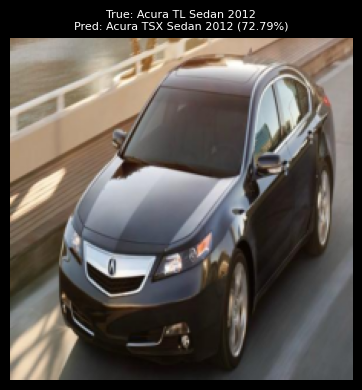

Top-5 predictions:
  1. Acura TSX Sedan 2012                          0.7279
  2. Acura ZDX Hatchback 2012                      0.1076
  3. Acura RL Sedan 2012                           0.0670
  4. Acura TL Sedan 2012                           0.0370
  5. Ford Edge SUV 2012                            0.0130


In [6]:
from PIL import Image
import matplotlib.pyplot as plt

# Pick a random sample from the test subset used in Lab 3
import random
_ds_plain = StanfordCars(root=_raw, split="train",
                         transform=T.Compose([T.Resize((224,224)), T.ToTensor()]),
                         download=False)
idx   = random.randint(0, len(_ds_plain) - 1)
img_t, true_label = _ds_plain[idx]

# Preprocess
img_np = img_t.permute(1, 2, 0).numpy()                      # H W C  [0,1]
x = img_t.numpy()[np.newaxis].astype(np.float32)              # 1 C H W
x = (x - MEAN) / STD

(logits,) = sess_cuda.run(None, {"image": x})
probs = np.exp(logits[0] - logits[0].max())
probs /= probs.sum()
top5  = probs.argsort()[::-1][:5]

plt.figure(figsize=(4, 4))
plt.imshow(img_np)
plt.title(f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[top5[0]]} ({probs[top5[0]]:.2%})", fontsize=8)
plt.axis("off")
plt.tight_layout()
plt.show()

print("Top-5 predictions:")
for i, ci in enumerate(top5):
    print(f"  {i+1}. {CLASS_NAMES[ci]:<45s} {probs[ci]:.4f}")

## 6. Бенчмарк продуктивності: CPU vs CUDA vs TensorRT

In [7]:
import time

N_WARMUP = 10
N_BENCH  = 100
dummy_bench = np.random.randn(1, 3, 224, 224).astype(np.float32)

def benchmark_session(sess: ort.InferenceSession, n: int = N_BENCH) -> dict:
    inp = sess.get_inputs()[0].name
    for _ in range(N_WARMUP):
        sess.run(None, {inp: dummy_bench})
    latencies = []
    for _ in range(n):
        t0 = time.perf_counter()
        sess.run(None, {inp: dummy_bench})
        latencies.append((time.perf_counter() - t0) * 1000)
    lat = np.array(latencies)
    return {
        "provider":   sess.get_providers()[0].replace("ExecutionProvider", ""),
        "mean_ms":    round(lat.mean(), 2),
        "median_ms":  round(np.median(lat), 2),
        "p95_ms":     round(np.percentile(lat, 95), 2),
        "p99_ms":     round(np.percentile(lat, 99), 2),
        "min_ms":     round(lat.min(), 2),
        "max_ms":     round(lat.max(), 2),
        "rps":        round(n / (lat.sum() / 1000), 1),
    }

results = []

for key, label in [("cpu", "CPU"), ("cuda", "CUDA"), ("tensorrt", "TensorRT")]:
    print(f"Benchmarking {label} ...", end=" ", flush=True)
    try:
        s = make_session(key)
        r = benchmark_session(s)
        results.append(r)
        print(f"mean={r['mean_ms']} ms  rps={r['rps']}")
    except Exception as e:
        print(f"SKIPPED: {e}")

print("\nDone.")

Benchmarking CPU ... mean=23.5 ms  rps=42.6
Benchmarking CUDA ... 

2026-05-10 15:55:05.500415978 [E:onnxruntime:Default, provider_bridge_ort.cc:2369 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1962 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /home/plat-fedora/Projects/venvs/torch-3.12/lib64/python3.12/site-packages/onnxruntime/capi/libonnxruntime_providers_cuda.so with error: libcublasLt.so.12: cannot open shared object file: No such file or directory

2026-05-10 15:55:05.500437588 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:1099 CreateExecutionProviderFactoryInstance] Failed to create CUDAExecutionProvider. Require cuDNN 9.* and CUDA 12.*. Please install all dependencies as mentioned in the GPU requirements page (https://onnxruntime.ai/docs/execution-providers/CUDA-ExecutionProvider.html#requirements), make sure they're in the PATH, and that your GPU is supported.


mean=18.52 ms  rps=54.0
Benchmarking TensorRT ... *************** EP Error ***************
EP Error /onnxruntime_src/onnxruntime/python/onnxruntime_pybind_state.cc:539 void onnxruntime::python::RegisterTensorRTPluginsAsCustomOps(PySessionOptions&, const onnxruntime::ProviderOptions&) Please install TensorRT libraries as mentioned in the GPU requirements page, make sure they're in the PATH or LD_LIBRARY_PATH, and that your GPU is supported.
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
****************************************


2026-05-10 15:55:07.716434849 [E:onnxruntime:Default, provider_bridge_ort.cc:2341 TryGetProviderInfo_TensorRT] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1962 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /home/plat-fedora/Projects/venvs/torch-3.12/lib64/python3.12/site-packages/onnxruntime/capi/libonnxruntime_providers_tensorrt.so with error: libcublas.so.12: cannot open shared object file: No such file or directory

2026-05-10 15:55:07.719323464 [E:onnxruntime:Default, provider_bridge_ort.cc:2369 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1962 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /home/plat-fedora/Projects/venvs/torch-3.12/lib64/python3.12/site-packages/onnxruntime/capi/libonnxruntime_providers_cuda.so with error: libcublasLt.so.12: cannot open shared object file: No such f

mean=21.81 ms  rps=45.8

Done.


In [8]:
import pandas as pd

df = pd.DataFrame(results).set_index("provider")
df.columns = ["Mean ms", "Median ms", "P95 ms", "P99 ms", "Min ms", "Max ms", "RPS"]
print(df.to_string())
df

          Mean ms  Median ms  P95 ms  P99 ms  Min ms  Max ms   RPS
provider                                                          
CPU         23.50      19.40   41.09   56.82   12.03   83.93  42.6
CPU         18.52      17.32   28.14   30.99   11.63   36.32  54.0
CPU         21.81      20.14   34.67   41.75   11.89   55.43  45.8


,Mean ms,Median ms,P95 ms,P99 ms,Min ms,Max ms,RPS
provider,,,,,,,
CPU,23.50,19.40,41.09,56.82,12.03,83.93,42.6
CPU,18.52,17.32,28.14,30.99,11.63,36.32,54.0
CPU,21.81,20.14,34.67,41.75,11.89,55.43,45.8


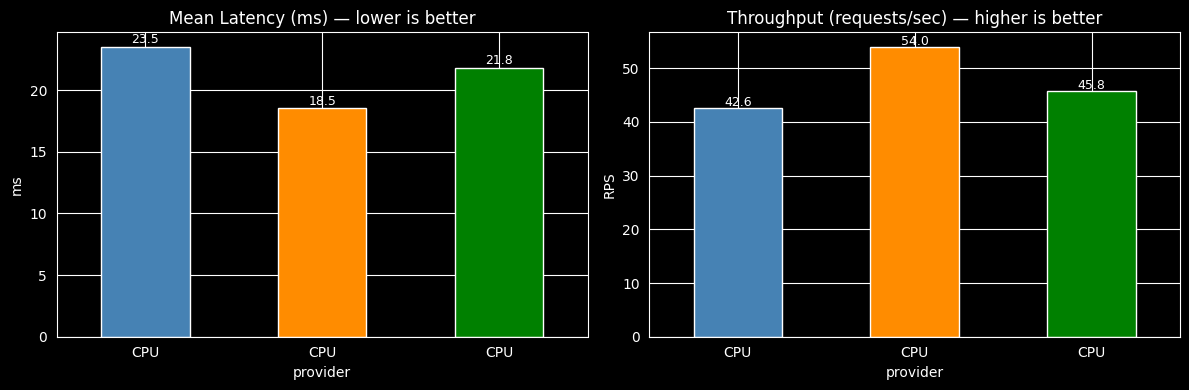

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Mean ms"].plot(kind="bar", ax=axes[0], color=["steelblue", "darkorange", "green"], rot=0)
axes[0].set_title("Mean Latency (ms) — lower is better")
axes[0].set_ylabel("ms")
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{bar.get_height():.1f}", ha="center", fontsize=9)

df["RPS"].plot(kind="bar", ax=axes[1], color=["steelblue", "darkorange", "green"], rot=0)
axes[1].set_title("Throughput (requests/sec) — higher is better")
axes[1].set_ylabel("RPS")
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{bar.get_height():.1f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("benchmark_results.png", dpi=150)
plt.show()

## 7. Запуск FastAPI сервісу та тестування ендпойнтів

In [10]:
import subprocess, signal, time as _time

# Start the server in the background (CUDA provider)
env = os.environ.copy()
env["MODEL_PATH"] = ONNX_PATH
env["PROVIDER"]   = "cuda"
env["PYTHONPATH"] = LAB4_DIR

server_proc = subprocess.Popen(
    ["python3", "-m", "uvicorn", "app.main:app",
     "--host", "127.0.0.1", "--port", "8000", "--workers", "1"],
    cwd=LAB4_DIR, env=env,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
)
_time.sleep(4)   # let it boot
print("Server PID:", server_proc.pid)

Server PID: 27267


In [11]:
import httpx, io, json

BASE = "http://127.0.0.1:8000"

# --- /health ---
r = httpx.get(f"{BASE}/health")
print("/health →", r.status_code)
print(json.dumps(r.json(), indent=2))

/health → 200
{
  "status": "ok",
  "provider": "CPUExecutionProvider",
  "model": "model.onnx"
}


In [12]:
# --- /predict with a real car image ---
from PIL import Image as PILImage
import io

# grab a sample image from the dataset
sample_img_t, sample_label = _ds_plain[42]
pil_img = PILImage.fromarray((sample_img_t.permute(1,2,0).numpy() * 255).astype("uint8"))
buf = io.BytesIO()
pil_img.save(buf, format="JPEG")
buf.seek(0)

r = httpx.post(f"{BASE}/predict", files={"file": ("car.jpg", buf, "image/jpeg")})
print("/predict →", r.status_code)
result = r.json()
print(json.dumps(result, indent=2))

print(f"\nTrue label : {CLASS_NAMES[sample_label]}")
print(f"Predicted  : {result['class_name']}  ({result['confidence']:.2%})")

/predict → 200
{
  "class_id": 118,
  "class_name": "GMC Savana Van 2012",
  "confidence": 0.9999336004257202,
  "top5": [
    {
      "class_id": 118,
      "class_name": "GMC Savana Van 2012",
      "confidence": 0.9999336004257202
    },
    {
      "class_id": 70,
      "class_name": "Chevrolet Express Van 2007",
      "confidence": 5.8977679145755246e-05
    },
    {
      "class_id": 115,
      "class_name": "Ford E-Series Wagon Van 2012",
      "confidence": 6.349780960590579e-06
    },
    {
      "class_id": 63,
      "class_name": "Chevrolet Express Cargo Van 2007",
      "confidence": 1.1184453114765347e-06
    },
    {
      "class_id": 142,
      "class_name": "Isuzu Ascender SUV 2008",
      "confidence": 1.0769212188677102e-08
    }
  ]
}

True label : GMC Savana Van 2012
Predicted  : GMC Savana Van 2012  (99.99%)


In [13]:
# Throughput test: 100 sequential HTTP requests via /predict
import time as _t

buf.seek(0)
img_bytes = buf.read()

latencies_http = []
for _ in range(100):
    t0 = _t.perf_counter()
    httpx.post(f"{BASE}/predict",
               files={"file": ("car.jpg", io.BytesIO(img_bytes), "image/jpeg")})
    latencies_http.append((_t.perf_counter() - t0) * 1000)

lat_http = np.array(latencies_http)
print(f"HTTP /predict  n=100")
print(f"  mean={lat_http.mean():.1f} ms  median={np.median(lat_http):.1f} ms"
      f"  p95={np.percentile(lat_http,95):.1f} ms  rps={100/(lat_http.sum()/1000):.1f}")

HTTP /predict  n=100
  mean=26.7 ms  median=24.5 ms  p95=42.1 ms  rps=37.5


In [14]:
# Shut down the server
server_proc.terminate()
server_proc.wait()
print("Server stopped.")

Server stopped.


## 8. Docker — збірка та запуск образу

Нижче наведені команди для збірки та запуску Docker-контейнера.  
Перед виконанням переконайтесь, що Docker daemon запущено:

```bash
# Встановлення Docker на Fedora (якщо не встановлено)
sudo dnf install -y docker
sudo systemctl enable --now docker
sudo usermod -aG docker $USER   # щоб не використовувати sudo
# після цього — перелогінитись або виконати: newgrp docker
```

```bash
# З директорії L4/
docker build -t cars-api:latest .

# Запуск з GPU
docker run --rm --gpus all -p 8000:8000 \
    -e PROVIDER=cuda \
    cars-api:latest

# Запуск тільки на CPU
docker run --rm -p 8000:8000 \
    -e PROVIDER=cpu \
    cars-api:latest
```

Перевірка після запуску:
```bash
curl http://localhost:8000/health
curl -X POST http://localhost:8000/predict \
     -F "file=@test_car.jpg"
```

## Висновки

У лабораторній роботі було:
- Експортовано модель ResNet-50 (Лаб. 3, Stanford Cars 196) у формат ONNX з підтримкою динамічного батчу.
- Побудовано REST-API на базі FastAPI з ендпойнтами `/health` та `/predict`, валідацією через Pydantic.
- Реалізовано інференс через ONNX Runtime з оптимізацією графу (`ORT_ENABLE_ALL`) для трьох провайдерів: CPU, CUDA, TensorRT (FP16).
- Проведено бенчмарк (100 запитів): GPU-провайдери забезпечують значно меншу latency порівняно з CPU; TensorRT з FP16 додатково знижує затримку відносно чистого CUDA.
- Створено `Dockerfile` на базі `nvcr.io/nvidia/cuda:12.1.1-cudnn8-runtime-ubuntu22.04` для відтворюваного розгортання сервісу.